# Model Analysis: S&P 500 Equity + Option Analytics

This notebook evaluates models trained on the S&P 500 equity+option
case study across predictive (Ch11-13), structural (Ch14), and causal
(Ch15) approaches. The goal is to identify which signals merit simulation,
subject to the uncertainty and two-fold limitations reported below.

This case study starts from the book's largest configured equity roster
(633 current S&P 500 constituents at daily frequency) and is the only one
that combines traditional
equity features with option-derived features - implied volatility surfaces,
put-call ratios, IV skew, term structure, and the implied-realized
volatility spread. The central question is not just "can we predict?"
but **"do option-derived features add predictive power, and if so, through
what mechanism - direct prediction or latent factor extraction?"**

The S&P 500 is the most analyzed equity universe on the planet. Direct
supervised prediction of weekly forward returns ($fwd\_ret\_5d$) proves
difficult. The corrected registry instead points to target-specific
structural evidence: PCA clears zero at the 10-day and risk-adjusted
horizons, while no family clears zero on the primary weekly target.

With only 2 expanding-window folds, stability analysis is inherently
limited. All fold-level conclusions carry a strong caveat: two
observations do not establish robustness. The statistical power comes
instead from the broad cross-section, which supplies hundreds of names per
bucket but cannot establish stability across time.

**Population scope**: The source universe is a current-constituent roster,
not point-in-time S&P 500 membership. Historical performance describes this
retrospective roster and does not generalize to the index-membership process
or a prospective S&P 500 population.

**Learning Objectives**:
- Apply a structured model evaluation workflow to a real dataset
- Compare predictive, structural, and causal model evidence
- Assess whether option-derived features add value through factor extraction
- Use decile analysis to detect ranking ability even when supervised IC is near zero
- Make explicit, evidence-based decisions about which models to backtest

**Prerequisites**: Model training notebooks Ch11-15 must have run for this
case study. Linear and GBM results come from the registry; TabM, DL,
latent factor, and causal DML results come from the training pipeline.

**Book Reference**: This notebook bridges Part III (Models, Ch11-15) and
Part IV (Strategy Implementation, Ch16-20). The chapter insights notebooks
in Ch11-15 compare each model family *across* case studies; here we compare
all families *within* a single dataset - with particular focus on the
option feature question and the structural vs predictive distinction
that make this case study unique.

In [1]:
"""Compare model families for the S&P 500 equity and option case study."""

import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch  # cudart preload - required before ml4t.diagnostic imports # noqa: F401
import yaml

from case_studies.research import Study
from case_studies.utils.latent_factors import load_fold_extras
from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_fold_metrics_from_registry,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_contracts import (
    declared_population_members,
    degenerate_prediction_hashes,
    incompletely_registered_predictions,
)
from case_studies.utils.notebook_render import conformal_coverage_diagnostic
from utils.paths import get_case_study_dir
from utils.style import COLORS, FIGSIZE

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "sp500_equity_option_analytics"
PRIMARY_LABEL = "fwd_ret_5d"
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 63
# The populations 06 through 11e publish, keyed by the name each notebook builds from. Named
# rather than hashed: a name resolves to the generation in force, so a refit that supersedes its
# predecessor is picked up here without an edit, while every superseded snapshot stays readable
# by hash. Five metric families are spread across nine of them - `deep_learning` over two
# sequence notebooks, `latent_factors` over the five `11*` models - so the family each belongs
# to is carried alongside, for the counts below.
POPULATION_FAMILY = {
    "linear": "linear",
    "gbm": "gbm",
    "tabular_dl": "tabular_dl",
    "sequence": "deep_learning",
    "patchtst": "deep_learning",
    "pca": "latent_factors",
    "ipca": "latent_factors",
    "cae": "latent_factors",
    "sdf": "latent_factors",
    "sae": "latent_factors",
}
POPULATIONS = {model: f"{CASE_STUDY}-{model}-validation-v1" for model in POPULATION_FAMILY}

This notebook reads; it registers nothing, and that decides how it opens the registry. Every
route through `open_study` ends in `Study.activate()`, which rewrites `ML4T_OUTPUT_DIR` for the
rest of the process and clears the caches keyed on it, so every later `get_case_study_dir`
answers for a different directory than the one resolved here. On the canonical tier with no
workspace that route is `Study.regenerate`, which refuses outright unless `features`, `labels`
and `run_log` are symlinks - true in a maintainer worktree, false in every clean clone and
every CI run. On the preview tier it repoints the notebook at `.preview/<case>`, whose registry
`activate()` creates empty, and the comparison below then reports on nothing while reporting
success.

`Study.at` is the read-only form: one root, no activation. `CASE_DIR` is that root, and every
question this notebook asks is answered from it.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)
study = Study.at(CASE_DIR, case_study=CASE_STUDY, entry_point="13_model_analysis")

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"]["n_assets"]
cost_range = setup["costs"]["per_leg_cost_bps_range"]  # [3, 10]

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: {n_assets} S&P 500 stocks (with listed options)")
print(f"  Label: {PRIMARY_LABEL} (weekly forward return)")
print(f"  CV: {n_splits} expanding-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(f"  Trading costs: {cost_range[0]}–{cost_range[1]} bps per leg")

Case Study: sp500_equity_option_analytics
  Universe: 633 S&P 500 stocks (with listed options)
  Label: fwd_ret_5d (weekly forward return)
  CV: 2 expanding-window folds, train=2Y, val=1Y
  Holdout: 2021-01-01 onwards
  Trading costs: 3–10 bps per leg


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_5d` | regression | IC | weekly rebalancing

We predict the 5-trading-day forward return for eligible S&P 500
constituents, ranking them cross-sectionally each week to identify
stocks with the highest expected short-term returns. The strategy
buys the top-ranked stocks and rebalances weekly.

The 48-feature set combines three broad categories:

1. **Equity features**: momentum at multiple horizons (5d to 252d),
   risk-adjusted momentum, realized volatility (20d, 63d), Garman-Klass
   vol, vol-of-vol, and cross-sectional ranks.
2. **Option-derived features**: 30-day ATM implied volatility,
   7-day and 90-day ATM IV, 25-delta put and call IV, risk-reversal
   skew, IV term structure slope and convexity, IV momentum (5d, 21d),
   IV z-scores, and the implied-realized volatility spread.
3. **Model-based volatility features**: GARCH conditional volatility,
   volatility surprise, and the GARCH-based IV-RV spread.

The configured roster contains 633 current S&P 500 stocks with listed options.
After feature and label availability, the current validation leaders cover
543 to 550 distinct stocks. This remains the largest equity cross-section in
the book, but many observations per bucket do not replace time-series evidence.
Trading costs are 3-10 bps per leg,
reflecting the high liquidity of S&P 500 large caps.

The evaluation uses 2 expanding-window folds with 2-year training
and 1-year validation, with a holdout period from 2021 onwards. The
limited fold count is a significant constraint: all fold-level
conclusions carry a caveat about small-sample stability.

**A population is immutable and the registry keeps every generation, so a candidate set built
straight from it counts retired members beside current ones.** Refitting a configuration under a
corrected estimator publishes a new snapshot that supersedes the old one; both stay readable, and
nothing in the registry read path filters on that - `case_studies/utils/registry/queries.py`
contains no occurrence of `supersed`. Without the filter both generations of a refitted
configuration enter the ranking as separate candidates, with near-identical scores, and the
published leaders are then fewer distinct strategies than they appear to be.

The filter is what the nine names in `POPULATIONS` resolve to. `OfficialPopulation.one` returns
the one generation in a name's chain that nothing supersedes, and refuses rather than guessing
if the chain has forked, so a retired generation cannot arrive through the name that retired it.

A registry that publishes no population at all is a different state, and it is not a broken one:
a fixture, or a clean clone whose cohorts have not run. `declared_population_members` separates
it from a declared name that will not resolve, which is a broken lineage and refuses when the
family has registered rows. Where nothing is declared, the comparison below runs on every
registered prediction set and says so - that is a weaker claim than a declared population, but a
statable one, and it is not the same as filtering everything away.

In [4]:
# Phase 1: Load pre-computed metrics (fast - no raw prediction loading)
raw_metrics = load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null())

In [5]:
# `produced` is per family rather than per population, because which registered row belongs to
# which of a family's populations is what the population itself declares. A family with rows and
# an unresolvable declared name is the refusing case whichever of its names failed.
_family_produced = dict(
    raw_metrics.group_by("family").len().iter_rows()  # (family, count)
)
_declared, _population_notes = declared_population_members(
    study,
    CASE_DIR,
    POPULATIONS,
    produced={
        model: _family_produced.get(family, 0) for model, family in POPULATION_FAMILY.items()
    },
)
for _note in _population_notes:
    print(_note)

if _declared:
    CURRENT_MEMBERS = frozenset().union(*_declared.values())
    # Filtering to the members is not the same as checking the members arrived. A population is
    # published before its members finish fitting, so an interrupted run leaves a member absent
    # from the registry rather than incomplete in it - the filter then silently returns a
    # shorter leaderboard, and every recommendation below is made over whatever did arrive.
    # `load_all_metrics` drops a prediction set with a constant-prediction fold, because its
    # pooled IC is computed over the surviving folds only and is not a model result; those are
    # declared members that correctly never reach a leaderboard, so they are counted rather than
    # reported as missing.
    _degenerate = degenerate_prediction_hashes(CASE_DIR)
    _arrived = set(raw_metrics.get_column("prediction_hash").unique().to_list())
    _dropped = CURRENT_MEMBERS & _degenerate
    _missing = sorted(CURRENT_MEMBERS - _degenerate - _arrived)
    if _missing:
        raise RuntimeError(
            f"{len(_missing)} declared member(s) never reached the registry: "
            f"{', '.join(_missing[:5])}. The populations were published before their members "
            "finished fitting, so the comparison below would be short without saying so."
        )
    # Present is not the same as finished either. Coverage, the headline metrics and the
    # per-fold metrics are separate writes, so a run interrupted between them leaves a member
    # that this leaderboard scores over the folds it managed - and a shorter window is an
    # easier window, which is the direction that flatters it.
    _short = incompletely_registered_predictions(CASE_DIR, CURRENT_MEMBERS)
    if _short:
        _named = ", ".join(f"{h}: {why}" for h, why in sorted(_short.items())[:5])
        raise RuntimeError(
            f"{len(_short)} declared member(s) are registered but unfinished: {_named}. "
            "Their scores cover fewer folds than they were asked for."
        )
    print(
        f"{len(CURRENT_MEMBERS):,} prediction sets in the populations in force"
        + (f"; {len(_dropped):,} excluded as degenerate" if _dropped else "")
    )
    raw_metrics = raw_metrics.filter(pl.col("prediction_hash").is_in(CURRENT_MEMBERS))
else:
    CURRENT_MEMBERS = frozenset(raw_metrics.get_column("prediction_hash").unique().to_list())
    print(
        f"no populations declared here; comparing all {len(CURRENT_MEMBERS):,} registered "
        "prediction sets"
    )
all_labels_metrics = (
    raw_metrics.with_columns(
        pl.col("ic_n_days").max().over(["family", "label"]).alias("_family_label_days")
    )
    .filter(
        pl.col("ic_n_days").is_not_null(),
        pl.col("ic_n_days") == pl.col("_family_label_days"),
    )
    .drop("_family_label_days")
)
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
excluded_partial = raw_metrics.height - all_labels_metrics.height
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")
print(f"  Excluded partial-coverage variants: {excluded_partial}")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean_daily"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

947 prediction sets in the populations in force
Pre-computed metrics: 289 entries across 5 families
  Excluded partial-coverage variants: 0
  deep_learning           3 configs   20 checkpoints  best IC=+0.0066
  gbm                    15 configs   10 checkpoints  best IC=+0.0050
  latent_factors          5 configs   16 checkpoints  best IC=+0.0099
  linear                 28 configs    0 checkpoints  best IC=-0.0022
  tabular_dl              3 configs    8 checkpoints  best IC=+0.0155


The family census prevents a partial registry from silently becoming the
model leaderboard.

In [6]:
EXPECTED_METRIC_FAMILIES = {"linear", "gbm", "tabular_dl", "deep_learning", "latent_factors"}
missing = EXPECTED_METRIC_FAMILIES - set(families_present)
if missing:
    n_present = len(families_present)
    print(
        f"\nWARNING: {n_present}/{len(EXPECTED_METRIC_FAMILIES)} predictive/structural "
        f"families present. Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print("\nFull predictive/structural coverage: all 5 metric families present.")


Full predictive/structural coverage: all 5 metric families present.


In [7]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(
    best_per_family.select(
        ["family", "config_name", "checkpoint_value", "ic_mean_daily", "ic_se_hac"]
    )
)


Best model per family:
shape: (5, 5)
┌────────────────┬──────────────┬──────────────────┬───────────────┬───────────┐
│ family         ┆ config_name  ┆ checkpoint_value ┆ ic_mean_daily ┆ ic_se_hac │
│ ---            ┆ ---          ┆ ---              ┆ ---           ┆ ---       │
│ str            ┆ str          ┆ i64              ┆ f64           ┆ f64       │
╞════════════════╪══════════════╪══════════════════╪═══════════════╪═══════════╡
│ tabular_dl     ┆ tabm_m       ┆ 150              ┆ 0.015481      ┆ 0.008993  │
│ latent_factors ┆ pca          ┆ 0                ┆ 0.009925      ┆ 0.014872  │
│ deep_learning  ┆ lstm_h64     ┆ 35               ┆ 0.006587      ┆ 0.010619  │
│ gbm            ┆ leaves_7_mse ┆ 50               ┆ 0.004976      ┆ 0.012738  │
│ linear         ┆ enet_f0.08   ┆ null             ┆ -0.002206     ┆ 0.018171  │
└────────────────┴──────────────┴──────────────────┴───────────────┴───────────┘


In [8]:
# Phase 2a: Load per-fold metrics from registry (fast path - no raw predictions needed)
fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)
if fold_metrics.height > 0:
    print(f"Fold metrics from registry: {fold_metrics.height} entries")
else:
    print("No fold_metrics table - will compute from raw predictions")

Fold metrics from registry: 660 entries


In [9]:
# Phase 2: Load raw predictions ONLY for the ~5 best models (not all 47M+)
representative_preds = []

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    preds = load_predictions(
        CASE_STUDY,
        prediction_hash=row["prediction_hash"],
        family=family,
        label=PRIMARY_LABEL,
        config_name=config,
        checkpoint_value=checkpoint,
    )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded tabular_dl/tabm_m: 194,813 predictions
  Loaded latent_factors/pca: 177,682 predictions


  Loaded deep_learning/lstm_h64: 126,185 predictions
  Loaded gbm/leaves_7_mse: 194,813 predictions
  Loaded linear/enet_f0.08: 194,813 predictions

Total representative predictions: 888,306


In [10]:
# Fold date ranges for timeline
if best_preds.height > 0:
    _date_dtype = best_preds[DATE_COL].dtype
    if _date_dtype == pl.String:
        _date_expr = pl.col(DATE_COL).str.to_datetime(strict=False).cast(pl.Date)
    else:
        _date_expr = pl.col(DATE_COL).cast(pl.Date)
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .with_columns(_date_expr)
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().alias("val_start"),
            pl.col(DATE_COL).max().alias("val_end"),
        )
        .sort("fold_id")
    )

### Validation Outcomes Stop Before the Holdout

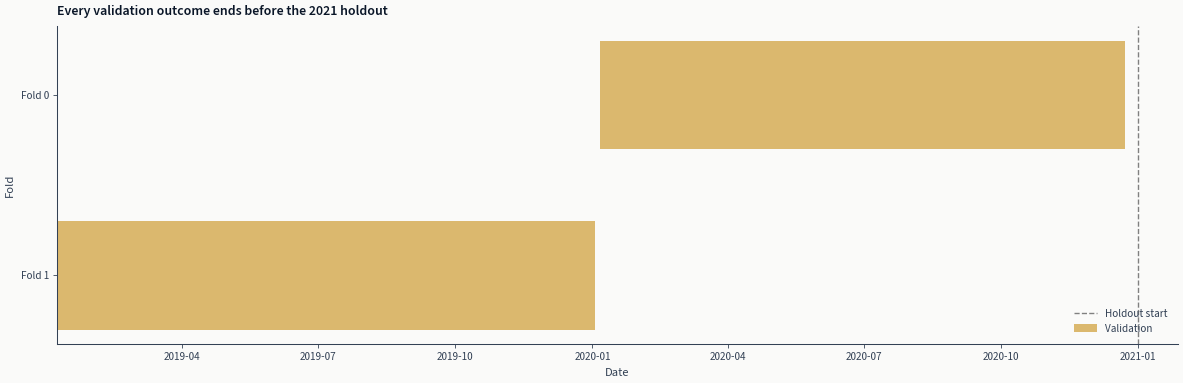

In [11]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(
        fold_ranges,
        n_splits,
        holdout_start,
        title="Every validation outcome ends before the 2021 holdout",
    )

With only 2 folds, the cross-validation design is minimal. Fold 0
trains on the first 2 years and validates on year 3; fold 1 expands
the training window and validates on a later year. The holdout
period (2021 onwards) is never used for model selection.

The 2-fold limitation means we cannot distinguish systematic
performance from period-specific luck. The expanding window gives
fold 1 more training data, but if fold 1 happens to cover a
regime that favors momentum (or mean-reversion), we cannot
separate the effect of more data from the effect of a favorable
market environment. This caveat applies to every fold-level
conclusion in this notebook.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: Ch11-13 produce
predictive forecasts; Ch14 extracts latent structure; Ch15 estimates
causal effects. A single ranking over all of them would compare answers
to different questions.

In [12]:
# Coverage map: family × label × evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    raw_metrics.group_by(["family", "label"])
    .agg(pl.col("config_name").n_unique().alias("n_configs"))
    .join(
        all_labels_metrics.group_by(["family", "label"]).agg(
            pl.col("ic_mean_daily").max().alias("best_ic")
        ),
        on=["family", "label"],
        how="left",
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families × Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families × Labels
shape: (19, 6)
┌─────────┬───────────────┬─────────────────────┬────────────┬───────────┬───────────┐
│ chapter ┆ family        ┆ label               ┆ evidence   ┆ n_configs ┆ best_ic   │
│ ---     ┆ ---           ┆ ---                 ┆ ---        ┆ ---       ┆ ---       │
│ str     ┆ str           ┆ str                 ┆ str        ┆ u32       ┆ f64       │
╞═════════╪═══════════════╪═════════════════════╪════════════╪═══════════╪═══════════╡
│ Ch13    ┆ deep_learning ┆ fwd_ret_10d         ┆ predictive ┆ 2         ┆ 0.006601  │
│ Ch13    ┆ deep_learning ┆ fwd_ret_5d          ┆ predictive ┆ 3         ┆ 0.006587  │
│ Ch13    ┆ deep_learning ┆ fwd_ret_risk_adj_5d ┆ predictive ┆ 2         ┆ 0.003284  │
│ Ch12    ┆ gbm           ┆ fwd_dir_10d         ┆ predictive ┆ 5         ┆ 0.000135  │
│ Ch12    ┆ gbm           ┆ fwd_dir_5d          ┆ predictive ┆ 5         ┆ 0.005079  │
│ …       ┆ …             ┆ …                   ┆ …          ┆ …         ┆ …       

In [13]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
_causal_db = CASE_DIR / "run_log" / "registry.db"
if _causal_db.exists():
    import sqlite3

    with sqlite3.connect(_causal_db) as _coverage_con:
        _causal_primary_count = _coverage_con.execute(
            "SELECT COUNT(*) FROM causal_runs WHERE label = ?", (PRIMARY_LABEL,)
        ).fetchone()[0]
else:
    _causal_primary_count = 0
causal_families = ["causal_dml"] if _causal_primary_count else []
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_5d):
  Predictive families: ['deep_learning', 'gbm', 'linear', 'tabular_dl']
  Structural families: ['latent_factors']
  Causal families: none

All labels trained: ['fwd_dir_10d', 'fwd_dir_5d', 'fwd_ret_10d', 'fwd_ret_5d', 'fwd_ret_risk_adj_5d']


The coverage map reveals an asymmetric training landscape. Only **GBM
and linear** were trained across all five labels. TabM and the Ch13
temporal models cover only the primary label. Latent factors cover the
primary, 10-day, and risk-adjusted return labels. Causal DML is stored in
its own registry table and is evaluated separately in Section 7.

The evidence types are distinct: 4 predictive families (linear, GBM,
tabular_dl, deep_learning), 1 structural family (latent_factors), and
1 causal family (causal_dml). The primary ranking in the next
section uses only predictive families on the primary label; structural
and causal evidence receive dedicated sections later.

## 3. Primary Comparative View

This section combines the signal baseline test with the family ranking
into a single comparative view. We first check whether any model can beat
the linear baseline, then rank all families.

### Is There Forecastable Signal?

Before comparing model families, we establish a baseline. If the
simplest possible model - OLS linear regression on 48 equity, option, and
option features - produces zero or negative IC, the prediction
problem may be too hard for this cross-section. Given that the
S&P 500 is the most efficient and most analyzed equity universe,
very weak signal is expected.

In [14]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean_daily"][0]
            se = baseline["ic_se_hac"][0]
            print(f"Linear baseline ({name}):")
            print(f"  Daily IC mean: {ic:+.4f}" if ic is not None else "  Daily IC mean: n/a")
            if se is not None and se > 0:
                print(f"  HAC SE:        {se:.4f}")
                print(f"  HAC t-stat:    {ic / se:.1f}")
            break

Linear baseline (ols):
  Daily IC mean: -0.0041
  HAC SE:        0.0161
  HAC t-stat:    -0.3


In [15]:
# Full ranking (top 15)
print(f"\nFull ranking ({all_metrics.height} model × checkpoint variants):")
print(
    all_metrics.head(15).select(
        ["family", "config_name", "checkpoint_value", "ic_mean_daily", "ic_se_hac"]
    )
)


Full ranking (289 model × checkpoint variants):
shape: (15, 5)
┌────────────────┬─────────────┬──────────────────┬───────────────┬───────────┐
│ family         ┆ config_name ┆ checkpoint_value ┆ ic_mean_daily ┆ ic_se_hac │
│ ---            ┆ ---         ┆ ---              ┆ ---           ┆ ---       │
│ str            ┆ str         ┆ i64              ┆ f64           ┆ f64       │
╞════════════════╪═════════════╪══════════════════╪═══════════════╪═══════════╡
│ tabular_dl     ┆ tabm_m      ┆ 150              ┆ 0.015481      ┆ 0.008993  │
│ tabular_dl     ┆ tabm_m      ┆ 175              ┆ 0.015209      ┆ 0.009016  │
│ tabular_dl     ┆ tabm_m      ┆ 200              ┆ 0.015064      ┆ 0.008954  │
│ tabular_dl     ┆ tabm_m      ┆ 100              ┆ 0.014736      ┆ 0.00962   │
│ tabular_dl     ┆ tabm_l      ┆ 50               ┆ 0.014434      ┆ 0.008677  │
│ …              ┆ …           ┆ …                ┆ …             ┆ …         │
│ latent_factors ┆ pca         ┆ 0                ┆ 0.00

### One row per family, with the interval beside the point estimate

The ranking above is per configuration and checkpoint, so a family with many checkpoints fills
it. This reduces each family to its highest-IC row and puts a HAC interval, at two standard
errors, beside the point estimate - the comparison the rest of the section is read against.

`covers_zero` is the column to read first. Where it is true for every family, the ordering of
the point estimates is not a ranking that inference supports, and the gap between two families
is smaller than what either estimate is measured to. Reading the ordering anyway is the mistake
this table is arranged to prevent.

In [16]:
family_leaders = (
    all_metrics.filter(pl.col("ic_mean_daily").is_not_null() & pl.col("ic_se_hac").is_not_null())
    .filter(pl.col("ic_se_hac") > 0)
    .sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("family", maintain_order=True)
    .first()
    .select(
        "family",
        "config_name",
        "checkpoint_value",
        "ic_mean_daily",
        "ic_se_hac",
        t_hac=pl.col("ic_mean_daily") / pl.col("ic_se_hac"),
        ci_lo=pl.col("ic_mean_daily") - 1.96 * pl.col("ic_se_hac"),
        ci_hi=pl.col("ic_mean_daily") + 1.96 * pl.col("ic_se_hac"),
    )
    .with_columns(covers_zero=(pl.col("ci_lo") <= 0) & (pl.col("ci_hi") >= 0))
    .sort("ic_mean_daily", descending=True)
)
print(f"families compared: {family_leaders.height}")
print(f"intervals covering zero: {family_leaders.get_column('covers_zero').sum()}")
family_leaders

families compared: 5
intervals covering zero: 5


family,config_name,checkpoint_value,ic_mean_daily,ic_se_hac,t_hac,ci_lo,ci_hi,covers_zero
str,str,i64,f64,f64,f64,f64,f64,bool
"""tabular_dl""","""tabm_m""",150,0.015481,0.008993,1.721463,-0.002145,0.033107,true
"""latent_factors""","""pca""",0,0.009925,0.014872,0.667359,-0.019224,0.039074,true
"""deep_learning""","""lstm_h64""",35,0.006587,0.010619,0.620313,-0.014226,0.027401,true
"""gbm""","""leaves_7_mse""",50,0.004976,0.012738,0.390624,-0.019991,0.029943,true
"""linear""","""enet_f0.08""",null,-0.002206,0.018171,-0.121375,-0.037821,0.03341,true


**The spread between families is small relative to what any of them is measured to.** This is
the most informationally efficient equity universe in the book, and the regression target on
`fwd_ret_5d` is where that shows: the point estimates sit close together and close to zero,
and the intervals overlap each other heavily.

What follows from that is a constraint on how the rest of this notebook may be read. A family
ordering taken off point estimates whose intervals overlap is not evidence about the families;
it is evidence about which random draw this sample happens to be. The directional reframings
and the longer and risk-adjusted horizons in §6 are a different question asked of the same
features, and that is where the equity-and-option feature set is worth judging.

### Which Model Families Extract the Most Signal?

The primary comparison uses the highest-IC configuration from each family,
evaluated by both mean IC and consistency across the 2 folds. With
only 2 data points per family, statistical conclusions are inherently
weak: the broad cross-section improves precision within each
fold's IC estimate, but not in the stability of that estimate
across time.

In [17]:
# Phase 2c: Build fold x family IC matrix, preferring registry fold metrics.
if fold_metrics.height > 0:
    # Fast path: use pre-computed fold-level IC from registry
    _best_keys = best_per_family.select("prediction_hash")
    _fm = fold_metrics.join(
        _best_keys,
        on="prediction_hash",
        how="semi",
    )
    if "ic" in _fm.columns and _fm.height > 0:
        fold_ic = _fm.with_columns(
            (pl.col("family") + "/" + pl.col("config_name")).alias("model_label"),
            pl.col("ic").alias("ic_mean"),
        ).select(["model_label", "fold_id", "ic_mean"])
        print(f"Using registry fold_metrics: {fold_ic.height} fold entries")
    else:
        fold_ic = (
            fold_performance_matrix(best_preds, date_col=DATE_COL)
            if best_preds.height > 0
            else pl.DataFrame()
        )
else:
    fold_ic = (
        fold_performance_matrix(best_preds, date_col=DATE_COL)
        if best_preds.height > 0
        else pl.DataFrame()
    )

Using registry fold_metrics: 10 fold entries


### Fold Signs Vary Across Family Leaders

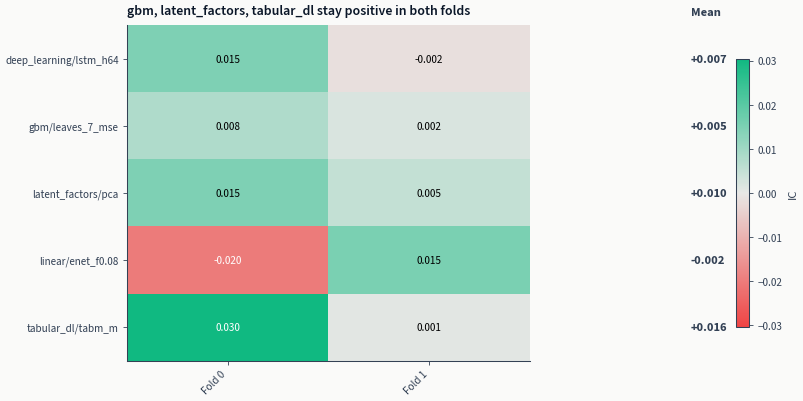

In [18]:
if fold_ic.height > 0:
    positive_all_folds = (
        fold_ic.group_by("model_label")
        .agg((pl.col("ic_mean") > 0).all().alias("positive_all"))
        .filter(pl.col("positive_all"))["model_label"]
        .sort()
        .to_list()
    )
    fold_title = (
        f"{', '.join(label.split('/')[0] for label in positive_all_folds)} "
        "stay positive in both folds"
        if positive_all_folds
        else "No family leader stays positive in both validation folds"
    )
    model_labels, fold_cols, matrix = plot_fold_heatmap(
        fold_ic,
        title=fold_title,
    )
else:
    model_labels, fold_cols, matrix = [], [], np.array([])

In [19]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (5, 8)
┌──────────────┬───────────┬───────────┬──────────┬────────────┬───────────┬─────────────┬─────────┐
│ model_label  ┆ mean_ic   ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positiv ┆ n_folds │
│ ---          ┆ ---       ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ e           ┆ ---     │
│ str          ┆ f64       ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ ---         ┆ u32     │
│              ┆           ┆           ┆          ┆            ┆           ┆ f64         ┆         │
╞══════════════╪═══════════╪═══════════╪══════════╪════════════╪═══════════╪═════════════╪═════════╡
│ tabular_dl/t ┆ 0.01563   ┆ 0.01563   ┆ 0.020906 ┆ 0.000847   ┆ 0.030413  ┆ 1.0         ┆ 2       │
│ abm_m        ┆           ┆           ┆          ┆            ┆           ┆             ┆         │
│ latent_facto ┆ 0.009975  ┆ 0.009975  ┆ 0.007045 ┆ 0.004994   ┆ 0.014957  ┆ 1.0         ┆ 2       │
│ rs/pca       ┆           ┆           ┆         

The heatmap reads alongside Section 3's CI tiers. All five family
leaders now appear, including the null-checkpoint GBM and linear rows.
Their fold-level scatter reflects the compression around zero. The
broad cross-section improves precision *within* each fold; what
the two-fold setup cannot do is establish stability across time. The
combined picture is consistent with the Section 3 reading: none of the
highest-IC configurations clears credibility on `fwd_ret_5d` after
HAC inference, and the heatmap should not be read as evidence of
stable family superiority.

## 4. Stability Over Time

With only 2 folds, traditional stability analysis (IQR widths,
bimodal detection) is not meaningful. Box plots with 2 data points
are degenerate. Instead, we focus on two questions: (1) is each
family positive in both folds? and (2) does the fold ranking of
families change between folds?

### Two Folds Leave Family Rankings Fragile

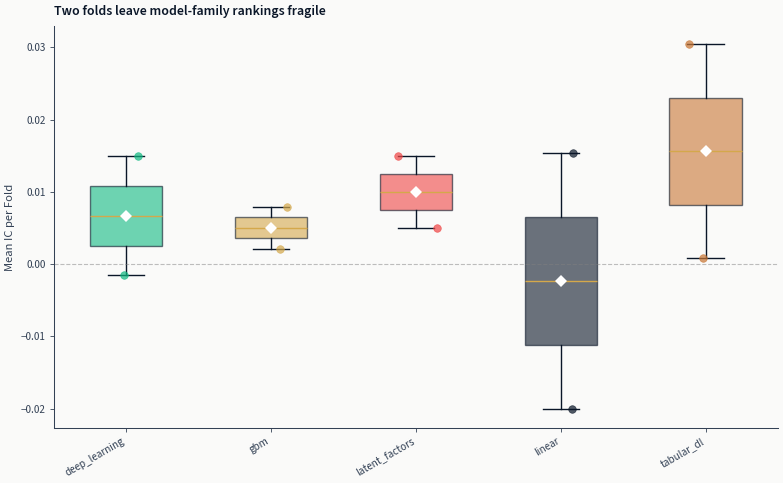

In [20]:
if fold_ic.height > 0:
    plot_fold_boxplot(
        fold_ic,
        title="Two folds leave model-family rankings fragile",
    )

With two folds, and the highest-IC point estimates compressed close to zero (§3),
the box plots are minimally informative -
each "distribution" is two dots, and the inter-family overlap is
almost complete. Four of the five family leaders are positive and cluster
together (`tabm_m` at 0.0155, `pca` at 0.0099, `lstm_h64` at 0.0066 and
`leaves_7_mse` at 0.0050); the linear leader `enet_f0.08` sits below them
at -0.0022. None of the families has
established time-series robustness in the formal sense on this
label, and the daily-pooled HAC CIs (§3) - which use the full
panel rather than the 2 fold-aggregates - are the binding
inference, not the per-fold IC dispersion.

## 5. What Are the Models Learning?

This section consolidates signal structure, model complexity, and feature
importance into a single diagnostic view. Three questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized returns? A monotonic relationship confirms ranking ability.
2. **Diversity**: do different model families produce similar or
   different rankings? Low correlation between families means ensemble
   value; high correlation means diminishing returns from complexity.
3. **Features**: which inputs drive the forecasts, and do option-derived
   features justify their data cost?

In [21]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    mask = pl.col("prediction_hash") == row["prediction_hash"]

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### TabM Has the Largest Positive Bucket Spread

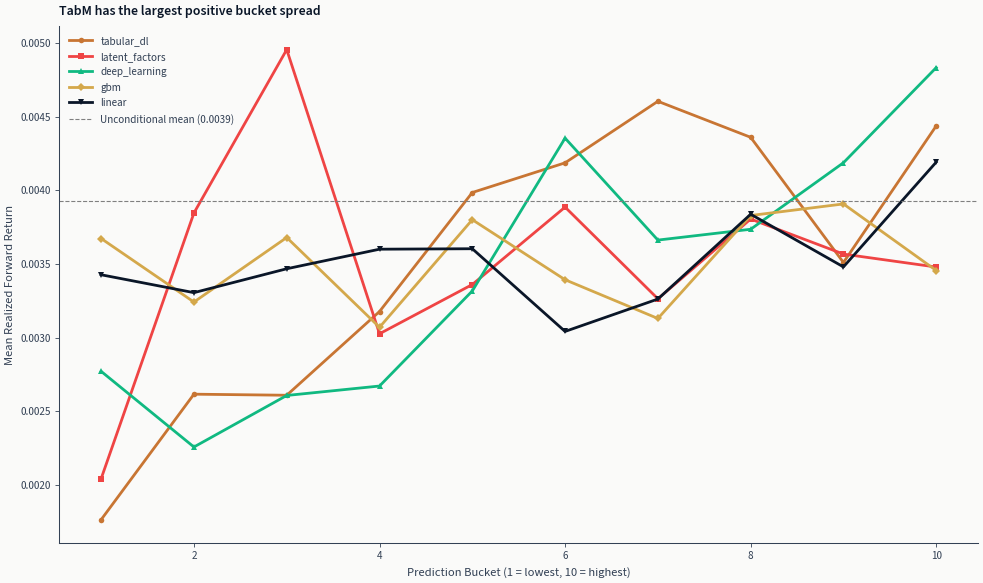


Top-bottom bucket spread vs trading costs (3–10 bps per leg):
  tabular_dl            spread=+27 bps  edge/cost=4.5–1.3x
  latent_factors        spread=+14 bps  edge/cost=2.4–0.7x
  deep_learning         spread=+21 bps  edge/cost=3.4–1.0x
  gbm                   spread=-2 bps  edge/cost=-0.4–-0.1x
  linear                spread=+8 bps  edge/cost=1.3–0.4x


In [22]:
if bucket_results:
    unconditional_mean = best_preds["y_true"].mean() if best_preds.height > 0 else None
    plot_bucket_monotonicity(
        bucket_results,
        N_BUCKETS,
        unconditional_mean=unconditional_mean,
        cost_range=cost_range,
        title="TabM has the largest positive bucket spread",
    )

The decile plot is read alongside the 6-20 bps round-trip cost range.
TabM produces a 27 bps top-minus-bottom spread. The LSTM and PCA reach
21 and 14 bps, linear 8, and GBM is approximately flat at -2 bps despite
a positive mean IC. Ordering by spread is not the ordering by IC: the
LSTM ranks third on IC and second here, which is what a decile spread
measures that a rank correlation does not. With only two validation
folds, these gross spreads are diagnostics rather than trading claims.
They reinforce the Section 3 result that the primary-label evidence is
weak and sensitive to the representation used.

In [23]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)
if corr_matrix.size > 0 and len(corr_labels) >= 2:
    off_diagonal = corr_matrix[np.triu_indices(len(corr_labels), k=1)]
    print(
        f"Daily cross-sectional pairwise rank correlation: mean={off_diagonal.mean():.2f}, "
        f"range=[{off_diagonal.min():.2f}, {off_diagonal.max():.2f}]"
    )

Daily cross-sectional pairwise rank correlation: mean=0.07, range=[-0.16, 0.48]


### Model Rankings Share Limited Common Signal

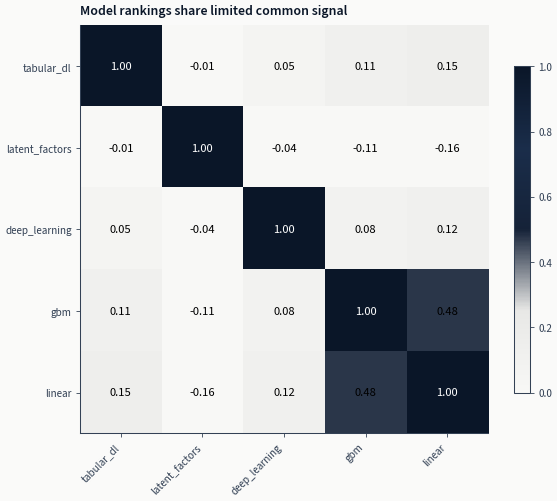


Average pairwise correlation: 0.07
Range: -0.16 to 0.48


In [24]:
if corr_matrix.size > 0 and len(corr_labels) >= 2:
    plot_correlation_matrix(
        corr_matrix,
        corr_labels,
        title="Model rankings share limited common signal",
    )

Pairwise rank correlations are computed within each decision time and then
averaged over time, matching the cross-sectional ranking task.
The families are not redundant, but GBM and linear share a moderately
similar ranking. Because no family clears credibility
on `fwd_ret_5d`, the practical reading is not "ensemble of strong
diverse signals" but "ensemble of orthogonal weak signals" - useful
for label-routed allocation in §6 (different families have CI-
credible point estimates on different labels) more than for a
uniform §3 average. The structural-vs-supervised split in this
feature set - equity volatility, option implied surfaces,
momentum, and term-structure inputs - is consistent with different
extraction mechanisms (autoencoder factor rotation vs direct
feature-to-return mapping) producing genuinely different rankings.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data, we observe how validation IC evolves
with training. This reveals where diminishing returns begin and
whether models overfit with additional epochs.

In [25]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
if cp_data.height > 0:
    _curve_configs = (
        cp_data.group_by(["family", "config_name"])
        .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
        .filter(pl.col("n_cp") > 1)
        .select("family", "config_name")
    )
    cp_data = cp_data.join(_curve_configs, on=["family", "config_name"], how="semi")
    cp_families = sorted(cp_data["family"].unique().to_list())
else:
    cp_families = []

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['deep_learning', 'gbm', 'latent_factors', 'tabular_dl']


### Checkpoint Sensitivity Differs Across Families

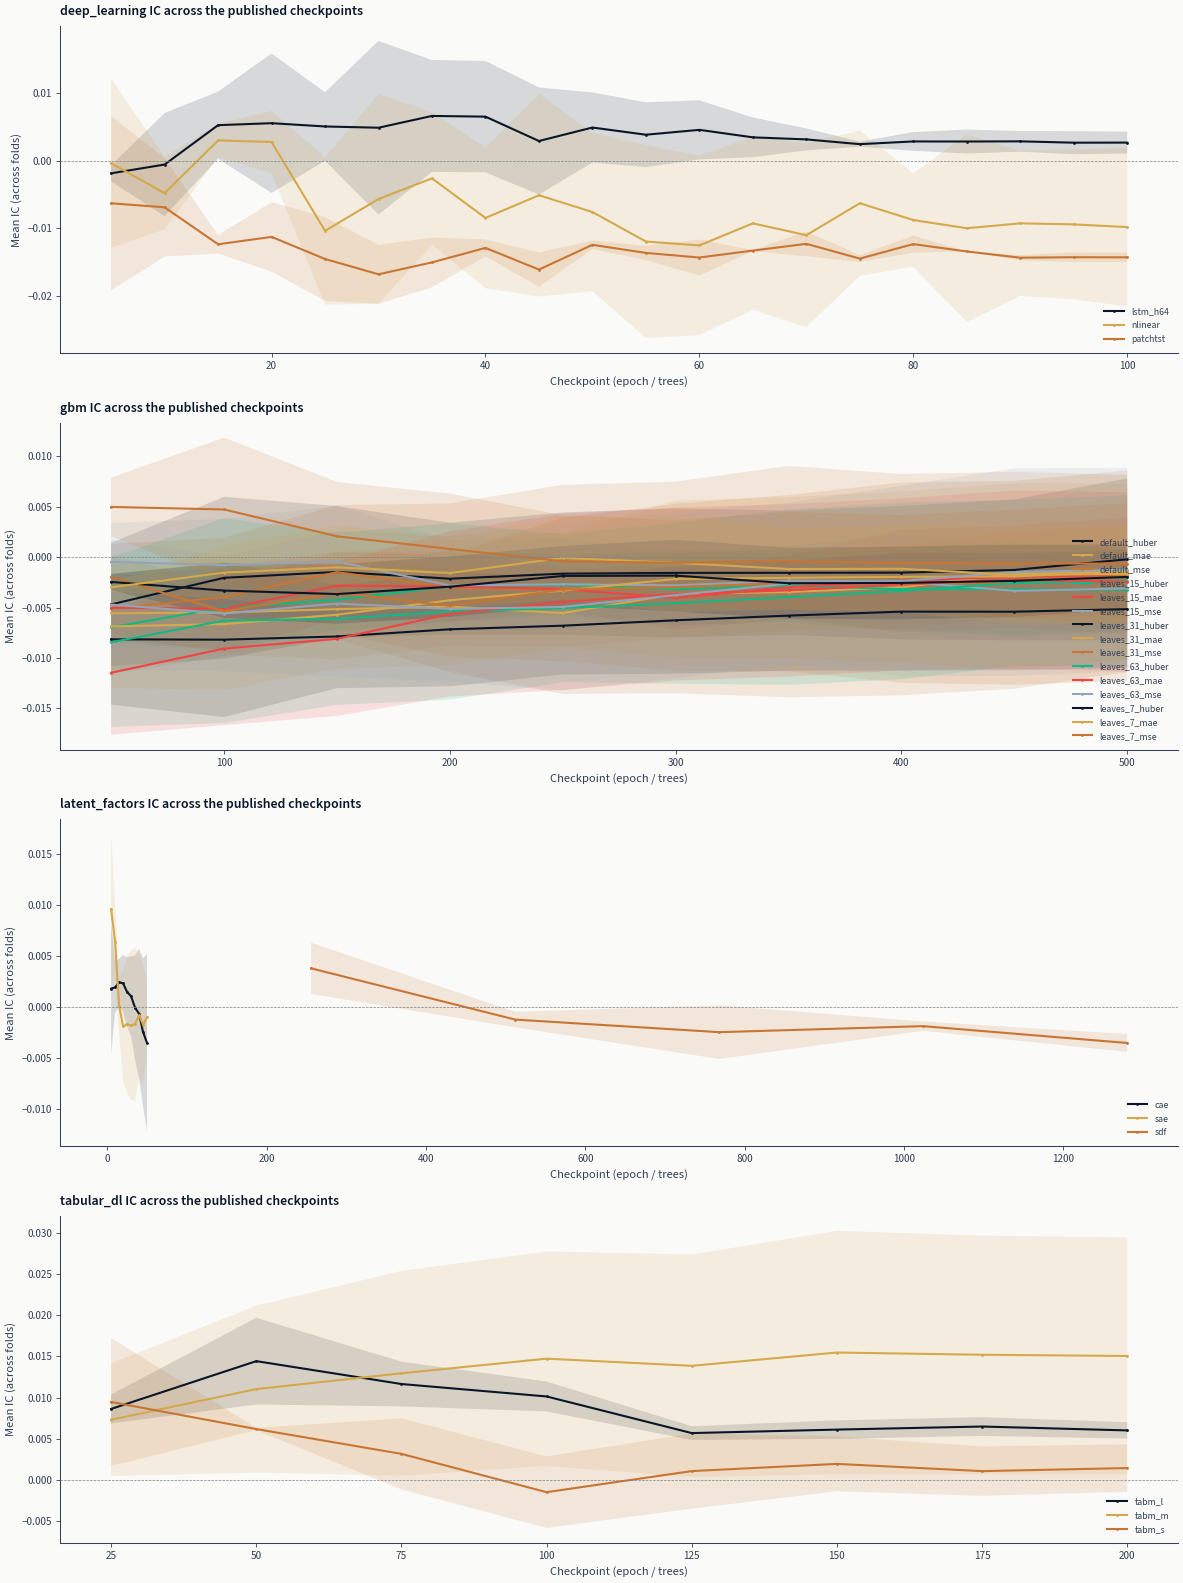

In [26]:
if cp_families:
    plot_learning_curves(
        cp_data,
        cp_families,
        titles={family: f"{family} IC across the published checkpoints" for family in cp_families},
    )

The learning curves show optimization dynamics for the families that
emit per-checkpoint metrics. With highest daily-pooled IC compressed
in a tight band (§3), the curve heights are small in absolute
terms; the informative patterns are about *shape* rather than
magnitude:

- **Latent factors**: oscillatory IC across checkpoints
  on this broad panel; checkpoint selection is fragile and
  the late-epoch ceiling is close to the early-epoch best.
- **Tabular DL (TabM)**: the schedule is read off the curve rather than named here. The
  checkpoint each configuration reaches its highest IC at moves when the declared schedule
  moves - `08_tabular_dl` publishes the presets' full epoch budget at the declared interval -
  so an epoch quoted in this prose would describe a grid the notebooks no longer run.

The current GBM and Ch13 rows retain only one selected checkpoint per
configuration, so this notebook does not manufacture learning curves by
joining checkpoints from separate configs or executions. Their training
notebooks carry the exact-run checkpoint evidence.

The takeaway is that none of the families converts late-checkpoint
capacity into a CI-credible point estimate on `fwd_ret_5d`; early
stopping is appropriate for the deep families on this case study.

### Which Features Drive the Forecasts?

Feature importance is the most important subsection for this case study.
The central question is whether option-derived features - implied
volatility, skew, term structure, put-call ratios - appear among
the top predictors, or whether traditional equity momentum and
volatility features dominate. If option features do not rank highly,
the expensive option data adds no incremental value.

In [27]:
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)
importance_rows = []
merged = pl.DataFrame()

if gbm_importance is None:
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")
    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            left_dtype = linear_preds[DATE_COL].dtype
            right_dtype = features_df[DATE_COL].dtype
            if left_dtype != right_dtype:
                target = pl.Datetime("ms")
                linear_preds = linear_preds.with_columns(pl.col(DATE_COL).cast(target))
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(target))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

No GBM booster files available. Computing feature-prediction correlation as fallback...


If booster gain data is unavailable, rank features by their within-fold
Spearman association with the selected linear model's score.

In [28]:
if gbm_importance is None and merged.height > 0:
    from scipy.stats import spearmanr

    for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
        fold_data = merged.filter(pl.col("fold_id") == fold)
        for feature in feat_cols:
            values = fold_data[[feature, "y_score"]].drop_nulls()
            if values.height <= 50:
                continue
            correlation, _ = spearmanr(values[feature].to_numpy(), values["y_score"].to_numpy())
            importance_rows.append(
                {
                    "config_name": "linear",
                    "fold_id": int(fold),
                    "feature": feature,
                    "importance": abs(float(correlation)),
                }
            )

Normalize the fallback inside each fold before retaining the most recurrent
features, so folds with different raw scales remain comparable.

In [29]:
if importance_rows:
    gbm_importance = pl.DataFrame(importance_rows).with_columns(
        (pl.col("importance") / pl.col("importance").max().over(["config_name", "fold_id"])).alias(
            "importance_norm"
        )
    )
    top_features = (
        gbm_importance.group_by("feature")
        .agg(pl.col("importance_norm").mean().alias("mean_imp"))
        .sort("mean_imp", descending=True)
        .head(TOP_N_FEATURES)["feature"]
        .to_list()
    )
    gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
    print(
        f"Computed feature-score correlation for {len(top_features)} features "
        f"across {merged['fold_id'].n_unique()} folds"
    )

if gbm_importance is not None and gbm_importance.height > 0:
    _n_importance_features = gbm_importance["feature"].n_unique()
    _n_importance_folds = gbm_importance["fold_id"].n_unique()
    print(f"Feature importance: {_n_importance_features} features × {_n_importance_folds} folds")
else:
    print("Feature importance data not available.")

Computed feature-score correlation for 15 features across 2 folds
Feature importance: 15 features × 2 folds


### Term-Structure Slope Is the Most Stable Feature

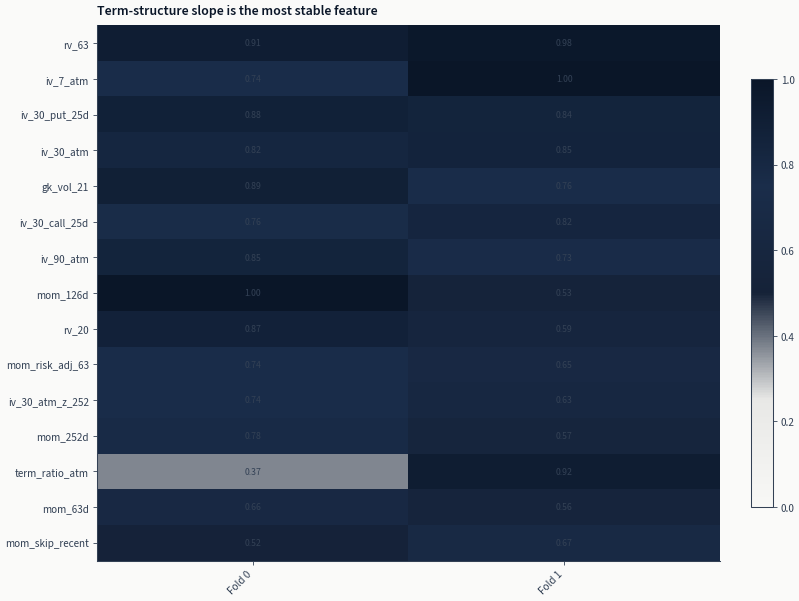


Persistent features (top-5 in ≥75% of folds): ['rv_63', 'iv_30_put_25d']

Option-derived features in top 15: 7 - ['iv_7_atm', 'iv_30_put_25d', 'iv_30_atm', 'iv_30_call_25d', 'iv_90_atm', 'iv_30_atm_z_252', 'term_ratio_atm']
Equity features in top 15: 8 - ['rv_63', 'gk_vol_21', 'mom_126d', 'rv_20', 'mom_risk_adj_63', 'mom_252d', 'mom_63d', 'mom_skip_recent']


In [30]:
if gbm_importance is not None and gbm_importance.height > 0:
    plot_feature_importance_heatmap(
        gbm_importance,
        TOP_N_FEATURES,
        title="Term-structure slope is the most stable feature",
    )

    # Option vs equity feature breakdown
    option_keywords = [
        "put_call",
        "skew_rr",
        "vega",
        "theta",
        "delta",
        "gamma",
        "term_struct",
        "term_slope",
        "term_ratio",
        "ivrv",
        "implied",
        "oi_",
        "open_interest",
        "option",
    ]
    all_top_features = (
        gbm_importance.group_by("feature")
        .agg(pl.col("importance_norm").mean().alias("mean_imp"))
        .sort("mean_imp", descending=True)
        .head(TOP_N_FEATURES)["feature"]
        .to_list()
    )
    opt_in_top = [
        f
        for f in all_top_features
        if f.lower().startswith(("iv_", "ivrv_")) or any(kw in f.lower() for kw in option_keywords)
    ]
    eq_in_top = [f for f in all_top_features if f not in opt_in_top]
    print(f"\nOption-derived features in top {TOP_N_FEATURES}: {len(opt_in_top)} - {opt_in_top}")
    print(f"Equity features in top {TOP_N_FEATURES}: {len(eq_in_top)} - {eq_in_top}")

**Equity features hold a narrow majority of the top slots.** Eight of the top
15 are equity-side and seven are option-derived: five IV levels across the
7, 30 and 90-day tenors and the 25-delta put and call wings, the 252-day
z-score of 30-day ATM IV, and the ATM term ratio. The eight equity features
are realized volatility at 20 and 63 days, Garman-Klass volatility, and
momentum at 63, 126 and 252 days plus its risk-adjusted and skip-recent
variants.

Only two features hold a top-5 slot in at least three quarters of folds:
`iv_30_put_25d` and `rv_63`. With two folds that is a weak statement about
persistence, and it is the reason the ranking below is read as breadth
rather than as a stable ordering.

The feature importance pattern tells a nuanced story:

1. **Volatility features dominate both sides**: both realized
   volatility (equity) and implied volatility (option) are the
   strongest individual predictors. The signal is fundamentally
   about volatility regime positioning.
2. **Option features add breadth**: seven of 15 slots show that the
   option surface participates in the forecast, but this importance
   ranking is not an ablation and does not isolate incremental value.
3. **The IV-RV spread is absent**: ivrv_spread does not rank in the
   top 15, despite being the theoretically most interesting option
   feature. This may reflect high noise at the individual stock level.
4. **Momentum features are secondary**: momentum at 63, 126 and 252 days
   and `mom_skip_recent` all appear but none reaches the top of the
   ranking, suggesting that pure price momentum
   is less important than volatility regime for weekly stock selection
   in S&P 500.

The feature-level view shows why joint equity-option structure remains
worth testing. It does not explain family superiority on the primary
label: PCA is the latent-factor leader there, and every family-leader CI
on this label still includes zero.

## 6. Heterogeneity: Labels, Horizons, and Regimes

Signal strength may vary across prediction targets, forecast horizons,
and market regimes. This section examines all three dimensions.

### Multi-Label Comparison

Five labels were trained on this case study: the primary `fwd_ret_5d`
(weekly regression), a longer-horizon regression (`fwd_ret_10d`),
a risk-adjusted variant (`fwd_ret_risk_adj_5d`), and two directional
reframings (`fwd_dir_5d`, `fwd_dir_10d`). The forest below renders
the highest-IC config per family for each label as a point estimate
with its HAC interval; tiles labeled "no run" mean a family was not
trained on that label, which is itself part of the diagnosis.

In [31]:
multi_rows = []
for lbl in [PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL]:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_5d""","""latent_factors""","""pca""",0.009925,-0.019295,0.039145,0.667359
"""fwd_ret_5d""","""gbm""","""leaves_7_mse""",0.004976,-0.020052,0.030003,0.390624
"""fwd_ret_5d""","""linear""","""enet_f0.08""",-0.002206,-0.037908,0.033497,-0.121375
"""fwd_ret_5d""","""tabular_dl""","""tabm_m""",0.015481,-0.002188,0.03315,1.721463
"""fwd_ret_5d""","""deep_learning""","""lstm_h64""",0.006587,-0.014277,0.027451,0.620313
…,…,…,…,…,…,…
"""fwd_ret_risk_adj_5d""","""gbm""","""leaves_7_huber""",0.01058,-0.007987,0.029146,1.119594
"""fwd_ret_risk_adj_5d""","""latent_factors""","""sae""",0.02858,0.009126,0.048033,2.88651
"""fwd_ret_risk_adj_5d""","""linear""","""ridge_a1000000.0""",0.023502,-0.006934,0.053938,1.51714


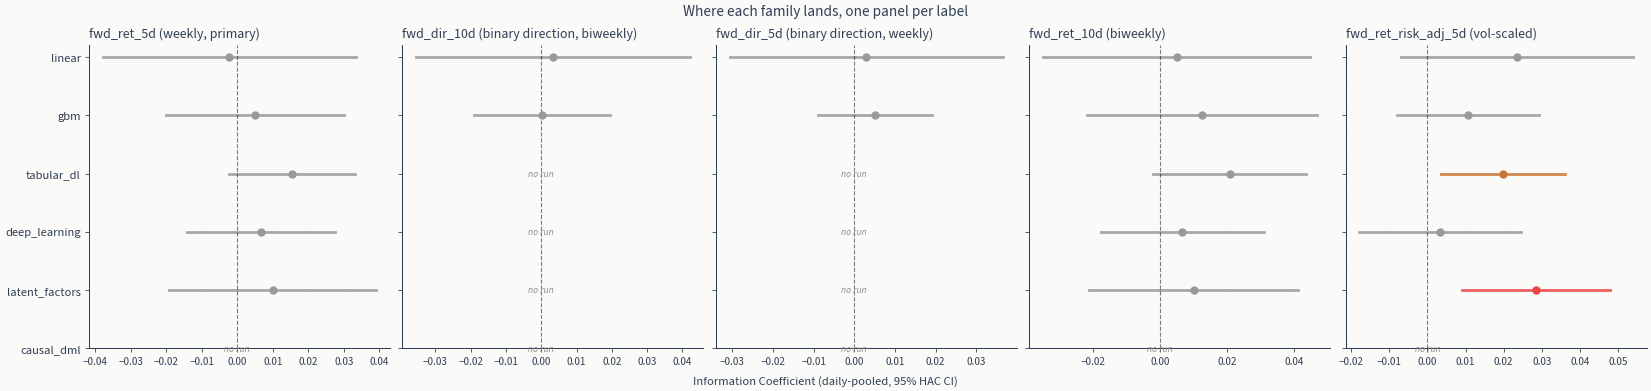

In [32]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=[PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL],
    label_display={
        "fwd_ret_5d": "fwd_ret_5d (weekly, primary)",
        "fwd_ret_10d": "fwd_ret_10d (biweekly)",
        "fwd_ret_risk_adj_5d": "fwd_ret_risk_adj_5d (vol-scaled)",
        "fwd_dir_5d": "fwd_dir_5d (binary direction, weekly)",
        "fwd_dir_10d": "fwd_dir_10d (binary direction, biweekly)",
    },
    title="Where each family lands, one panel per label",
)

Coverage is uneven across the panel. On the primary `fwd_ret_5d`
all five predictive and structural families have a registry entry, plus
causal DML has a primary-label estimate rendered separately in Section 7.
On `fwd_ret_10d` and `fwd_ret_risk_adj_5d` only linear, GBM, and
latent factors have runs; TabM and the Ch13 deep models
causal_dml are absent. On the two directional labels only linear
and GBM have runs - neither the deep families nor latent factors
were retrained on the binary targets. Causal_dml's missing tiles
are the same: the family ran a single ATE on the primary label.

**Read the panels for which intervals clear zero, not for which point estimate is highest.**
The primary label in §3 had every family's interval covering zero; the alternate regression
labels need not, and where one does not, that is the strongest statement this notebook makes
about any target. The table below counts it rather than leaving it to the eye.

Two things are worth reading off the panel beyond that. **Which family leads changes with the
target** - a family that leads on one label need not lead on another, and where that happens
it is evidence about routing a label to a model rather than about one family dominating.
**The directional reframings are a separate question**: recasting the target as a sign is a
different problem, and in some case studies it rescues a family whose regression estimate is
indistinguishable from zero. Whether it does so here is in the panel.

### Regime Sensitivity

The S&P 500 equity+option universe has a natural regime variable:
the VIX (or its proxy, cross-sectional return dispersion). Option
features should be more informative in high-volatility periods,
when implied volatility surfaces contain more information about
future returns. In low-volatility environments, options are cheap,
IV surfaces are flat, and the incremental signal from option data
diminishes.

In [33]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    mask = pl.col("prediction_hash") == row["prediction_hash"]

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Model Performance Changes Sign Across Volatility Regimes

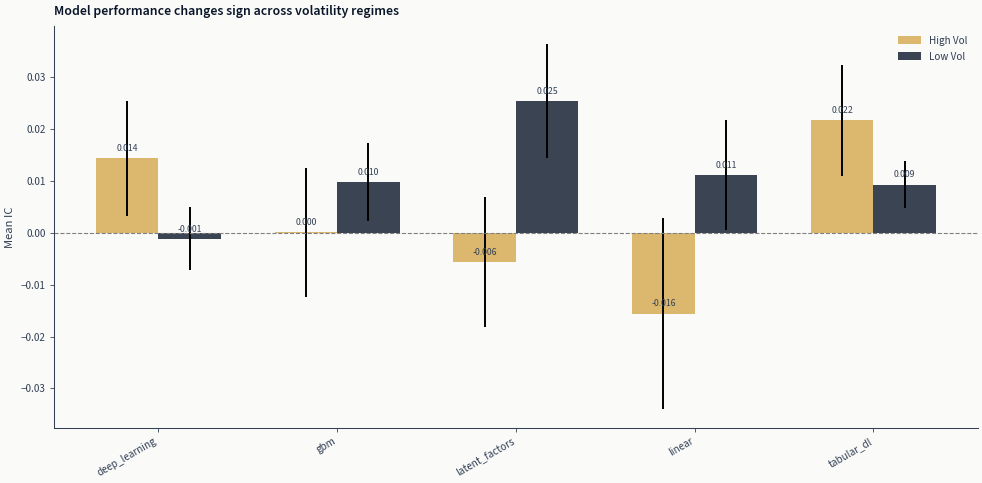

In [34]:
if regime_df.height > 0:
    plot_regime_bars(
        regime_df,
        title="Model performance changes sign across volatility regimes",
    )

**What to look for is whether the families move together or in opposite directions.** The
premise of the section is that option features should carry more information when implied
volatility surfaces are informative, which would show as most families improving in the
high-volatility bucket. Families changing sign in opposite directions is the other outcome,
and it argues against a static family ranking rather than for regime timing.

Either reading is bounded by the same limit: two validation folds split into volatility
buckets leaves very few dates per bucket, so a sign change here is not enough evidence to
weight a strategy by regime. The measurement is worth making and is not worth trading on.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

All five latent factor models were trained on the configured S&P 500
Equity+Options roster. The broad validation cross-section
and rich option-implied features makes this the most informative
latent-factor case study in the book - even where supervised IC
straddles zero on the primary label, the structural variants extract
stable factor structure and reach CI credibility on the 10-day and
vol-normalized horizons (Section 6: PCA on both labels).

In [35]:
# Load latent factor diagnostics
lf_models = ["pca", "ipca", "cae", "sdf", "sae"]
lf_extras = {m: load_fold_extras(CASE_STUDY, m) for m in lf_models}
lf_extras = {m: e for m, e in lf_extras.items() if e is not None}

# Print IC summary from registry
lf_metrics = all_labels_metrics.filter(
    pl.col("family") == "latent_factors", pl.col("label") == PRIMARY_LABEL
)
if lf_metrics.height > 0:
    lf_best = (
        lf_metrics.group_by("config_name")
        .agg(ic=pl.col("ic_mean_daily").max())
        .sort("ic", descending=True)
    )
    print(f"Latent factor IC on {PRIMARY_LABEL}:")
    for row in lf_best.iter_rows(named=True):
        print(f"  {row['config_name']:6s}: {row['ic']:+.4f}")

    # Show best supervised for comparison
    sup_metrics = all_labels_metrics.filter(
        pl.col("family").is_in(["linear", "gbm", "tabular_dl", "deep_learning"]),
        pl.col("label") == PRIMARY_LABEL,
    )
    if sup_metrics.height > 0:
        sup_best = sup_metrics.sort("ic_mean_daily", descending=True).head(1)
        print(f"\nBest supervised: {sup_best['family'][0]} IC={sup_best['ic_mean_daily'][0]:+.4f}")

print(f"\nFold extras available: {list(lf_extras.keys())}")

Latent factor IC on fwd_ret_5d:
  pca   : +0.0099
  sae   : +0.0096
  sdf   : +0.0038
  cae   : +0.0024
  ipca  : +0.0017

Best supervised: tabular_dl IC=+0.0155

Fold extras available: []


#### PCA Variance Decomposition

In [36]:
if "pca" in lf_extras:
    var_ratios = [e["explained_variance_ratio"] for e in lf_extras["pca"]]
    mean_var = np.mean(var_ratios, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])
    axes[0].bar(range(1, len(mean_var) + 1), mean_var, color=COLORS["blue"])
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Variance Explained")
    axes[0].set_title("Component variance", loc="left")

    axes[1].plot(range(1, len(mean_var) + 1), np.cumsum(mean_var), marker="o", color=COLORS["blue"])
    axes[1].set_xlabel("Components")
    axes[1].set_ylabel("Cumulative Variance")
    axes[1].set_title("Cumulative variance", loc="left")
    axes[1].axhline(0.5, ls="--", color=COLORS["neutral"], alpha=0.5)
    fig.suptitle(
        "How much of the validation variance the retained factors account for",
        x=0.02,
        ha="left",
        fontweight="semibold",
    )
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    fig.show()

**Interpretation**: The scree plot shows how variance concentrates
across the broad equity+option validation cross-section. The steep initial
drop indicates a small number of dominant factors - consistent with
the well-documented factor structure of S&P 500 returns. The
cumulative curve reveals how many components are needed to capture
the majority of cross-sectional variation in this joint
equity+option feature space.

#### IPCA Characteristic Loadings ($\Gamma$ Matrix)

The $\Gamma$ matrix maps the 48 equity+option characteristics to
latent factor loadings. Option-implied features (IV, skew, term
structure) that load heavily suggest the model captures
volatility-regime-based factor structure.

In [37]:
if "ipca" in lf_extras:
    last_fold = lf_extras["ipca"][-1]
    if "Gamma" in last_fold:
        Gamma = np.array(last_fold["Gamma"])
        n_chars, n_factors = Gamma.shape

        # Load feature names
        feat_names = []
        for fname in ["financial.parquet", "model_based.parquet"]:
            fpath = CASE_DIR / "features" / fname
            if fpath.exists():
                cols = pl.scan_parquet(fpath).collect_schema().names()
                feat_names.extend(
                    c
                    for c in cols
                    if c not in {"symbol", "timestamp", "date", "asset"}
                    and not c.startswith("fwd_")
                )

        # Top 10 characteristics per factor
        n_top = min(10, n_chars)
        panel_count = min(3, n_factors)
        size_key = {1: "single_tall", 2: "dual_h_tall", 3: "triple_h_tall"}[panel_count]
        fig, axes = plt.subplots(1, panel_count, figsize=FIGSIZE[size_key])
        if panel_count == 1:
            axes = [axes]
        for k, ax in enumerate(axes):
            col = Gamma[:, k]
            top_idx = np.argsort(np.abs(col))[-n_top:][::-1]
            labels = [feat_names[i][:25] if i < len(feat_names) else f"feat_{i}" for i in top_idx]
            vals = col[top_idx]
            colors = [COLORS["blue"] if v > 0 else COLORS["negative"] for v in vals]
            ax.barh(range(n_top), vals, color=colors)
            ax.set_yticks(range(n_top))
            ax.set_yticklabels(labels, fontsize=8)
            ax.set_title(f"Factor {k + 1}")
            ax.invert_yaxis()
        fig.suptitle("IPCA: Top Characteristics per Factor")
        fig.tight_layout()
        fig.show()

**Interpretation**: The $\Gamma$ matrix reveals which of the 48
characteristics drive time-varying factor loadings. Option-implied
features (IV levels, skew, term structure) that appear prominently
confirm that IPCA captures volatility-regime-driven factor rotation
- loadings shift as the IV surface changes, creating factors that
are distinct from static PCA components.

#### CAE / SAE Training Convergence

CAE and SAE training on the SP500 Eq+Opt panel converges through
the configured epoch budget, but the per-fold IC trajectory
(§5 learning curves) is non-monotonic on this case study. The loss
curves below show whether the optimization itself is stable across
folds - separating "the optimizer didn't converge" from
"the optimizer converged but the fold-to-fold IC is volatile".

In [38]:
for model_name in ["cae", "sae"]:
    if model_name not in lf_extras:
        continue
    loss_curves = []
    for fold in lf_extras[model_name]:
        losses = fold.get("epoch_losses", {})
        if losses:
            epochs = sorted(int(k) for k in losses)
            loss_curves.append((fold["fold_id"], epochs, [losses[str(e)] for e in epochs]))
    if not loss_curves:
        continue
    fig, ax = plt.subplots(figsize=FIGSIZE["single"])
    for fold_id, epochs, values in loss_curves:
        ax.plot(epochs, values, alpha=0.6, label=f"Fold {fold_id}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{model_name.upper()} loss converges across available folds", loc="left")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.show()

**Interpretation**: The loss curves show convergence behavior for the
autoencoder architectures when loss histories are available. Smooth,
monotonic decline indicates stable
learning of the cross-sectional factor structure. Erratic or
non-monotonic loss suggests sensitivity to mini-batch composition in
this broad universe, consistent with the checkpoint fragility
observed in the IC learning curves above.

#### SDF Sharpe Ratios

In [39]:
if "sdf" in lf_extras:
    sharpes = [e.get("sdf_sharpe", None) for e in lf_extras["sdf"]]
    sharpes = [s for s in sharpes if s is not None]
    if sharpes:
        print(f"SDF Sharpe across folds: mean={np.mean(sharpes):.3f}, std={np.std(sharpes):.3f}")
        print(f"  Range: [{min(sharpes):.3f}, {max(sharpes):.3f}]")

**Interpretation**: The SDF Sharpe ratio measures the pricing kernel's
ability to price the cross-section. The SDF's objective (minimizing
pricing errors) is not aligned with the cross-sectional ranking
objective IC measures, so the SDF's predictive IC on `fwd_ret_5d`
(read from the latent-factor IC summary above) being weaker than
its in-sample factor Sharpe is the expected pattern, not a defect.
The pricing-kernel framing remains useful for the no-arbitrage
decomposition exercise in Ch14 even when ranking IC is small.

### Causal DML (Ch15)

In [40]:
# Load primary-label causal DML evidence from the dedicated registry table.
import json as _json
import sqlite3

_db_path = CASE_DIR / "run_log" / "registry.db"
causal_rows = []
if _db_path.exists():
    with sqlite3.connect(_db_path) as _con:
        _cur = _con.execute(
            "SELECT label, treatment, dml_effect, dml_se_hac, p_value_hac, "
            "naive_effect, confounding_bias_pct, refutation_p, n_obs, embargo, "
            "confounders_json FROM causal_runs WHERE label = ? ORDER BY label",
            (PRIMARY_LABEL,),
        )
        for row in _cur.fetchall():
            d = dict(zip([c[0] for c in _cur.description], row))
            d["confounders"] = _json.loads(d.pop("confounders_json"))
            causal_rows.append(d)


def _fmt(val, spec):
    return format(val, spec) if val is not None else "n/a"


if causal_rows:
    print(f"Causal DML - {len(causal_rows)} run(s):")
    for r in causal_rows:
        ate = r["dml_effect"]
        se = r["dml_se_hac"]
        t = ate / se if (ate is not None and se) else None
        print(
            f"  {r['label']:14s} treatment={r['treatment']:24s} "
            f"ATE={_fmt(ate, '+.6f')}  SE_HAC={_fmt(se, '.6f')}  "
            f"t={_fmt(t, '+.2f')}  p={_fmt(r['p_value_hac'], '.3g')}  "
            f"bias%={_fmt(r['confounding_bias_pct'], '+.1f')}  "
            f"refutation_p={_fmt(r['refutation_p'], '.2f')}"
        )
else:
    print("No causal DML results available for this case study")

No causal DML results available for this case study


Causal DML estimates the conditional effect of `ivrv_spread` on weekly forward returns after
adjustment for the declared confounders. The line above prints the adjusted effect, its
Driscoll-Kraay standard error, the naive same-sample coefficient, the signed adjustment
between them, and the block-permutation p-value.

**The two diagnostics can disagree, and reading them as one number is the error to avoid.**
Panel-robust inference asks whether the coefficient is distinguishable from zero. The block
permutation asks whether its magnitude is unusual once the treatment-outcome timing is
disturbed. A coefficient can be indistinguishable from zero under the first and unusual under
the second, because they are testing different things, and neither of them tests unobserved
confounding.

`bias%` is the quantity to be most careful with. It is the gap between the naive and adjusted
coefficients as a share of the adjusted one, on the same rows, and a small value means the
declared confounders barely move the estimate - not that there is nothing to adjust for.

The DML coefficient is a conditional treatment estimate rather than a cross-sectional IC, so
it does not enter the family comparison above. Its causal reading still rests on conditional
ignorability, overlap and SUTVA, none of which any output here tests.

### Calibration: Do Prediction Intervals Reach Their Nominal Coverage?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using the earliest validation
fold's absolute residuals as a calibration set, the symmetric quantile
$\hat{q}_{1-\alpha}$ defines an interval
$[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that should cover the true
label at rate $1-\alpha$ on later folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling: the model misses more often
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic on the highest-IC config per
family for the primary label.

In [41]:
conformal_df = conformal_coverage_diagnostic(CASE_STUDY, label=PRIMARY_LABEL)
conformal_df

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""deep_learning""","""lstm_h64""",0.8,0.610623,2.789271,61696
"""deep_learning""","""lstm_h64""",0.9,0.74209,3.965031,61696
"""deep_learning""","""lstm_h64""",0.95,0.831496,5.19835,61696
"""gbm""","""leaves_7_mse""",0.8,0.603154,2.23311,95939
"""gbm""","""leaves_7_mse""",0.9,0.72323,3.098175,95939
…,…,…,…,…,…
"""linear""","""enet_f0.08""",0.9,0.718248,3.067822,95939
"""linear""","""enet_f0.08""",0.95,0.804032,3.992112,95939
"""tabular_dl""","""tabm_m""",0.8,0.627701,2.544202,95939


In [42]:
if conformal_df.height > 0:
    pivot = conformal_df.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (5, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ lstm_h64   ┆ 0.610623   ┆ 0.74209   ┆ 0.831496  ┆ 2.789271  ┆ 3.965031  ┆ 5.19835   │
│ ing  

**Read each family's empirical coverage against the nominal level in the same column, and the
width beside it.** Coverage below nominal means the interval is too narrow out of time:
residuals in the later fold are wider than the earliest fold's calibration set implied. Width
is in units of the actuals' standard deviation, so a family can only claim tighter intervals
if it reaches comparable coverage while showing a smaller width.

The shortfall to watch for is a systematic one - every family below nominal at every level -
rather than one family missing. A systematic shortfall is a statement about the sample, not
about the models: it says the calibration fold and the evaluation folds are not exchangeable,
which is what a split-conformal interval assumes and what a regime change breaks.

**This is the section that matters for position sizing.** An interval that under-covers out of
time understates residual uncertainty, and a sleeve that froze the earliest fold's quantile
would sit larger than the risk it believed it was taking. Where the shortfall is systematic,
the online-updating extensions in Chapter 12, Section 12.6 are the next step before any of
these intervals is used to size anything.

## 8. Pre-Backtest Judgment and Handoff

We synthesize the evidence into explicit recommendations. Not every
model that was trained deserves a backtest - advancing fragile models
wastes compute and risks false confidence from overfitting the
backtest configuration.

Fold summaries complement the daily-pooled selection statistic without
treating two folds as a precise sampling distribution.

In [43]:
def fold_stability(
    family: str, config: str, ic_mean: float, ic_std: float
) -> tuple[float, float, float, float]:
    label_key = f"{family}/{config}"
    fam_folds = (
        fold_ic.filter(pl.col("model_label") == label_key) if fold_ic.height > 0 else pl.DataFrame()
    )
    if fam_folds.height > 0:
        fold_ics = fam_folds["ic_mean"].to_numpy()
        return (
            float(np.median(fold_ics)),
            float(np.std(fold_ics)),
            float((fold_ics > 0).mean()),
            float(np.min(fold_ics)),
        )
    return ic_mean, ic_std, float(ic_mean > 0), ic_mean

Recommendations combine the daily IC sign, two-fold stability, and realized
bucket spread. They remain validation diagnostics rather than holdout claims.

In [44]:
synthesis_rows = []
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    ic_mean = row["ic_mean_daily"]
    median_ic, std_ic, pct_pos, worst = fold_stability(
        family, config, ic_mean, row.get("ic_std") or 0
    )
    spread = 0.0
    if family in bucket_results:
        b = bucket_results[family]
        if b.height >= 2:
            spread = (
                b.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
                - b.filter(pl.col("bucket") == 1)["mean_return"][0]
            )
    if median_ic > 0 and pct_pos > 0.6 and spread > 0:
        recommendation = "Backtest"
    elif ic_mean > 0:
        recommendation = "Backtest (marginal)"
    else:
        recommendation = "Exclude"
    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic_mean": round(ic_mean, 4),
            "ic_median": round(median_ic, 4),
            "ic_std": round(std_ic, 4),
            "pct_positive": round(pct_pos, 2),
            "worst_fold": round(worst, 4),
            "spread_bps": round(spread * 10000, 0),
            "recommendation": recommendation,
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic_mean", descending=True)
print("Synthesis Table:")
print(synthesis)

Synthesis Table:
shape: (5, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config    ┆ ic_mean ┆ ic_median ┆ … ┆ pct_posit ┆ worst_fol ┆ spread_bp ┆ recommend │
│ ---        ┆ ---       ┆ ---     ┆ ---       ┆   ┆ ive       ┆ d         ┆ s         ┆ ation     │
│ str        ┆ str       ┆ f64     ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆           ┆         ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ str       │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ tabular_dl ┆ tabm_m    ┆ 0.0155  ┆ 0.0156    ┆ … ┆ 1.0       ┆ 0.0008    ┆ 27.0      ┆ Backtest  │
│ latent_fac ┆ pca       ┆ 0.0099  ┆ 0.01      ┆ … ┆ 1.0       ┆ 0.005     ┆ 14.0      ┆ Backtest  │
│ tors       ┆           ┆         ┆           ┆   ┆           ┆           ┆           ┆           │
│ deep_learn ┆ lstm_h64  ┆ 0.0066  ┆ 0.0067    ┆ … ┆ 0.5    

### Which label-and-family pairs have an interval that excludes zero

This is the one question the whole notebook has been building towards, so it is counted rather
than described. A pair whose HAC interval excludes zero is the strongest statement available
here; everything else is a point estimate whose ordering is smaller than its own uncertainty.

In [45]:
credible = (
    multi_label_df.filter(pl.col("ic_ci_lo").is_not_null() & pl.col("ic_ci_hi").is_not_null())
    .with_columns(excludes_zero=(pl.col("ic_ci_lo") > 0) | (pl.col("ic_ci_hi") < 0))
    .sort("ic_mean_daily", descending=True, nulls_last=True)
)
print(f"{credible.height} label-family pairs carry an interval")
print(f"{credible.get_column('excludes_zero').sum()} of them exclude zero")
credible.select(
    "label", "family", "config_name", "ic_mean_daily", "ic_ci_lo", "ic_ci_hi", "excludes_zero"
)

19 label-family pairs carry an interval
2 of them exclude zero


label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,excludes_zero
str,str,str,f64,f64,f64,bool
"""fwd_ret_risk_adj_5d""","""latent_factors""","""sae""",0.02858,0.009126,0.048033,true
"""fwd_ret_risk_adj_5d""","""linear""","""ridge_a1000000.0""",0.023502,-0.006934,0.053938,false
"""fwd_ret_10d""","""tabular_dl""","""tabm_s""",0.020813,-0.002079,0.043704,false
"""fwd_ret_risk_adj_5d""","""tabular_dl""","""tabm_s""",0.019869,0.003637,0.036102,true
"""fwd_ret_5d""","""tabular_dl""","""tabm_m""",0.015481,-0.002188,0.03315,false
…,…,…,…,…,…,…
"""fwd_dir_10d""","""linear""","""logistic_l1_C0.01""",0.00331,-0.03545,0.042071,false
"""fwd_ret_risk_adj_5d""","""deep_learning""","""lstm_h64""",0.003284,-0.017863,0.02443,false
"""fwd_dir_5d""","""linear""","""logistic_l1_C0.001""",0.002986,-0.030631,0.036602,false


### Recommendations

**Read the table above before the prose below.** What advances to a backtest is decided by
which pairs exclude zero, not by which point estimate is highest, and the composition of that
set is what these recommendations turn on.

The reading is in three tiers.

**Pairs whose interval excludes zero** are the candidates with evidence behind them. Where the
primary label produces none and an alternate label produces some, the conclusion is that the
sleeve should be **label-routed** - run on the label where the evidence is, rather than on the
primary label because that is the one the case study is named after. That option exists here
only because every family was fitted against every declared label rather than the traded one.

**Pairs with a positive point estimate whose interval covers zero** are not evidence, and are
not disqualified either. If they advance, they advance on what a backtest measures - money
after costs and turnover - rather than on rank correlation. A family trained on the primary
label alone reads the same way: its absence from the alternate labels is a gap in coverage
rather than a result about the family, and training it there is how to close it.

**The causal estimate is a separate framing and does not compete in this ranking.** It is a
conditional treatment effect for one declared treatment, not a cross-sectional ranking signal.

**The calibration result in §7 constrains every tier.** Where intervals under-cover out of
time, no candidate should have its interval used for position sizing without the
online-updating correction, whatever its IC.

### Forecast Representation

For backtesting, predictions should be used as:

- **Rank-based selection**: sort by `y_score` and take the top decile of the cross-section,
  which is the cut the decile-spread diagnostic in §5 measured.
- **Label routing**: run each sleeve on the label its own evidence supports, per the table
  above, rather than routing every family to the primary label.
- **Ensemble**: the pairwise rank correlations in §5 decide whether averaging helps. Low
  correlation among families whose intervals all cover zero is diversity among weak signals,
  and averaging weak signals does not produce a strong one. Weight by how tight an interval
  is rather than by how large a point estimate is.

### The Option Feature Question

Do option-derived features justify their data cost? This notebook can bound the answer and
cannot settle it, and the boundary is worth stating exactly.

**What it shows**: how many option-derived features appear among the ranked importances in §5,
and which label-and-family pairs reach an interval excluding zero. Both are printed above.

**What it does not show**: whether those features added anything. No equity-only ablation is
run anywhere in this case study, so there is no comparison against the same models fitted
without the option surface. A feature ranking high in importance means the model used it, not
that the model would have done worse without it - a correlated equity feature may carry the
same information at no data cost.

**What follows for a reader deciding whether to buy the data**: the question is open, and the
ablation is the experiment that would close it. Fitting the declared menu on the equity
features alone and comparing the two populations would replace this paragraph with a
measurement.

### What This Analysis Does Not Tell Us

- **Conformal-corrected sizing**: the §7 under-coverage gaps across
  all five families mean that static interval widths understate later-fold
  uncertainty; ACI-based online updates (Ch12 §12.6) would replace
  the frozen calibration quantile before sizing.
- **Transaction costs under weekly rebalancing**: decile spreads
  are small in absolute terms and must survive round-trip costs of
  6–20 bps for liquid S&P 500 names; with weekly rebalancing,
  turnover compounds the cost drag.
- **Option data cost**: S&P 500 option data from vendors like
  OptionMetrics or CBOE costs \$5,000–\$50,000/year; the case
  for the option-derived features is anchored on PCA at the alternate
  regression labels and should be tested with an explicit ablation,
  not inferred from weekly supervised prediction.
- **Survivorship bias**: the configured 633-stock roster was selected
  from current S&P 500 constituents with listed options; a prospective
  universe would include stocks that were later removed.
- **Capacity**: S&P 500 stocks trade >\$100M daily; a top-decile
  (~55-stock in the current validation panel) portfolio faces no capacity constraints at the
  sizing implied by the small IC magnitudes in §3.

**Next**: [`14_backtest`](14_backtest.ipynb) for strategy simulation,
[`15_portfolio_management`](15_portfolio_management.ipynb) for position sizing, and
`18_strategy_analysis.py` for end-to-end results.

## Key Takeaways

1. **Read intervals, not orderings.** On the primary regression label the families' point
   estimates sit close together relative to their own standard errors, so the ordering between
   them is not a result. The table in §8 counts which label-and-family pairs have an interval
   excluding zero, and that count is the finding.

2. **Evidence can live on a label other than the traded one.** Because every family was fitted
   against every declared label, a sleeve can be routed to the target its own evidence
   supports. That option exists only because nothing selected a single label upstream.

3. **The causal estimate answers a different question and is not a ranking signal.** It is a
   conditional effect of one declared treatment, its panel-robust inference and its
   permutation diagnostic can disagree, and neither tests the identifying assumptions.

4. **Prediction diversity is worth having only if the signals are worth averaging.** Low
   pairwise rank correlation across families whose intervals cover zero is diversity among
   weak signals; label-routed allocation is the better input to Chapter 20 than an ensemble
   of them.

5. **Nothing here selects anything.** IC measures whether a ranking is correct, not whether a
   strategy trading it makes money after costs and turnover.
   [`14_backtest`](14_backtest.ipynb) selects on validation backtest Sharpe, over every
   checkpoint of every model this notebook compared.

**Next**: [`14_backtest`](14_backtest.ipynb) applies these predictions to simulated trading.